# Config

In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)


start=last_week
end=today

In [3]:
# Query
df = entsoe_client.query_generation_import(
    country_code=country_code,
    start=last_week,
    end=today)

# EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-08-11 00:00:00+02:00 to 2026-08-17 23:45:00+02:00
Freq: 15min
Data columns (total 17 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   (Generation, Biomass)                          672 non-null    float64
 1   (Generation, Energy storage)                   672 non-null    float64
 2   (Generation, Fossil Gas)                       672 non-null    float64
 3   (Generation, Fossil Hard coal)                 672 non-null    float64
 4   (Generation, Fossil Oil)                       672 non-null    float64
 5   (Generation, Hydro Pumped Storage)             672 non-null    float64
 6   (Generation, Hydro Run-of-river and poundage)  672 non-null    float64
 7   (Generation, Hydro Water Reservoir)            672 non-null    float64
 8   (Generation, Nuclear)                          672 non-null    float64
 9   (Gen

In [5]:
df.head()

Generation                            \
                             Biomass Energy storage Fossil Gas   
2026-08-11 00:00:00+02:00      524.0            0.0    13928.0   
2026-08-11 00:15:00+02:00      504.0            0.0    14000.0   
2026-08-11 00:30:00+02:00      488.0            0.0    13964.0   
2026-08-11 00:45:00+02:00      492.0            0.0    13788.0   
2026-08-11 01:00:00+02:00      496.0            0.0    13828.0   

                                                                            \
                          Fossil Hard coal Fossil Oil Hydro Pumped Storage   
2026-08-11 00:00:00+02:00              0.0       20.0               2336.0   
2026-08-11 00:15:00+02:00              0.0       20.0               2140.0   
2026-08-11 00:30:00+02:00              0.0       20.0               2144.0   
2026-08-11 00:45:00+02:00              0.0       20.0               2004.0   
2026-08-11 01:00:00+02:00              0.0       20.0               2024.0   

                                                           \
                          Hydro Run-of-river and poundage   
2026-08-11 00:00:00+02:00                           556.0   
2026-08-11 00:15:00+02:00                           544.0   
2026-08-11 00:30:00+02:00                           532.0   
2026-08-11 00:45:00+02:00                           532.0   
2026-08-11 01:00:00+02:00                           528.0   

                                                                               \
                          Hydro Water Reservoir Nuclear Other Other renewable   
2026-08-11 00:00:00+02:00                1836.0  5948.0   8.0            64.0   
2026-08-11 00:15:00+02:00                1528.0  5948.0   8.0            60.0   
2026-08-11 00:30:00+02:00                1132.0  5948.0   8.0            64.0   
2026-08-11 00:45:00+02:00                1080.0  5952.0   8.0            64.0   
2026-08-11 01:00:00+02:00                 920.0  5952.0   8.0            64.0   

                                                      Import               
                           Solar  Waste Wind Onshore      FR   PT     sum  
2026-08-11 00:00:00+02:00  512.0  244.0       4644.0  605.76  0.0  605.76  
2026-08-11 00:15:00+02:00  504.0  244.0       4652.0  896.68  0.0  896.68  
2026-08-11 00:30:00+02:00  500.0  244.0       4516.0  943.16  0.0  943.16  
2026-08-11 00:45:00+02:00  492.0  244.0       4352.0  958.08  0.0  958.08  
2026-08-11 01:00:00+02:00  492.0  244.0       4084.0  975.80  0.0  975.80

In [6]:
df.columns

MultiIndex([('Generation',                         'Biomass'),
            ('Generation',                  'Energy storage'),
            ('Generation',                      'Fossil Gas'),
            ('Generation',                'Fossil Hard coal'),
            ('Generation',                      'Fossil Oil'),
            ('Generation',            'Hydro Pumped Storage'),
            ('Generation', 'Hydro Run-of-river and poundage'),
            ('Generation',           'Hydro Water Reservoir'),
            ('Generation',                         'Nuclear'),
            ('Generation',                           'Other'),
            ('Generation',                 'Other renewable'),
            ('Generation',                           'Solar'),
            ('Generation',                           'Waste'),
            ('Generation',                    'Wind Onshore'),
            (    'Import',                              'FR'),
            (    'Import',                             

In [7]:
df.describe().T.round(2)

count      mean       std     min  \
Generation Biomass                          672.0    461.74     49.88   324.0   
           Energy storage                   672.0      0.71      7.14   -24.0   
           Fossil Gas                       672.0   8691.73   4469.59  2460.0   
           Fossil Hard coal                 672.0     66.51     86.57     0.0   
           Fossil Oil                       672.0     19.29      6.81     4.0   
           Hydro Pumped Storage             672.0     49.10   2426.60 -4124.0   
           Hydro Run-of-river and poundage  672.0    552.40     71.99   412.0   
           Hydro Water Reservoir            672.0   1473.88   1115.29   272.0   
           Nuclear                          672.0   5999.61    126.27  5880.0   
           Other                            672.0      9.26      2.95     4.0   
           Other renewable                  672.0     65.61      3.07    56.0   
           Solar                            672.0  11165.96  11640.96    48.0   
           Waste                            672.0    243.13     15.67   208.0   
           Wind Onshore                     672.0   3299.01   1763.47   352.0   
Import     FR                               672.0    769.74    875.24     0.0   
           PT                               672.0      8.83     67.87     0.0   
           sum                              672.0    778.57    872.77     0.0   

                                               25%      50%       75%  \
Generation Biomass                           428.0   472.00    500.00   
           Energy storage                      0.0     0.00      0.00   
           Fossil Gas                       3979.0  8756.00  13171.00   
           Fossil Hard coal                    0.0     0.00    164.00   
           Fossil Oil                         16.0    20.00     28.00   
           Hydro Pumped Storage            -2698.0  1042.00   1980.00   
           Hydro Run-of-river and poundage   496.0   552.00    592.00   
           Hydro Water Reservoir             556.0  1160.00   2096.00   
           Nuclear                          5948.0  5964.00   5980.00   
           Other                               8.0     8.00     12.00   
           Other renewable                    64.0    64.00     68.00   
           Solar                             504.0  4428.00  23733.00   
           Waste                             236.0   248.00    256.00   
           Wind Onshore                     1786.0  3106.00   4653.00   
Import     FR                                  0.0   594.24   1126.35   
           PT                                  0.0     0.00      0.00   
           sum                                 0.0   608.80   1128.03   

                                                 max  
Generation Biomass                            564.00  
           Energy storage                      36.00  
           Fossil Gas                       16120.00  
           Fossil Hard coal                   208.00  
           Fossil Oil                          28.00  
           Hydro Pumped Storage              3340.00  
           Hydro Run-of-river and poundage    792.00  
           Hydro Water Reservoir             4648.00  
           Nuclear                           6588.00  
           Other                               16.00  
           Other renewable                     72.00  
           Solar                            29672.00  
           Waste                              264.00  
           Wind Onshore                      9076.00  
Import     FR                                3483.28  
           PT                                 919.84  
           sum                               3483.28

In [8]:
# GENERATION by source in MWh
generation_mwh = df.xs(
    "Generation", 
    axis=1, 
    level=0
) * 0.25

generation_mwh

,Biomass,Energy storage,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Other renewable,Solar,Waste,Wind Onshore
2026-08-11 00:00:00+02:00,131.0,0.0,3482.0,0.0,5.0,584.0,139.0,459.0,1487.0,2.0,16.0,128.0,61.0,1161.0
2026-08-11 00:15:00+02:00,126.0,0.0,3500.0,0.0,5.0,535.0,136.0,382.0,1487.0,2.0,15.0,126.0,61.0,1163.0
2026-08-11 00:30:00+02:00,122.0,0.0,3491.0,0.0,5.0,536.0,133.0,283.0,1487.0,2.0,16.0,125.0,61.0,1129.0
2026-08-11 00:45:00+02:00,123.0,0.0,3447.0,0.0,5.0,501.0,133.0,270.0,1488.0,2.0,16.0,123.0,61.0,1088.0
2026-08-11 01:00:00+02:00,124.0,0.0,3457.0,0.0,5.0,506.0,132.0,230.0,1488.0,2.0,16.0,123.0,61.0,1021.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-17 22:45:00+02:00,105.0,5.0,3344.0,0.0,7.0,557.0,171.0,939.0,1639.0,2.0,18.0,137.0,55.0,1664.0
2026-08-17 23:00:00+02:00,105.0,5.0,3316.0,0.0,7.0,595.0,165.0,911.0,1641.0,3.0,18.0,131.0,55.0,1679.0
2026-08-17 23:15:00+02:00,104.0,1.0,3275.0,0.0,7.0,501.0,165.0,786.0,1643.0,4.0,18.0,127.0,55.0,1700.0
2026-08-17 23:30:00+02:00,104.0,0.0,3249.0,0.0,7.0,495.0,163.0,682.0,1645.0,4.0,18.0,122.0,55.0,1731.0


In [9]:
# IMPORT by source in MWh
import_mwh = df.xs(
    "Import", 
    axis=1, 
    level=0
).drop(columns="sum") * 0.25

import_mwh

,FR,PT
2026-08-11 00:00:00+02:00,151.44,0.0
2026-08-11 00:15:00+02:00,224.17,0.0
2026-08-11 00:30:00+02:00,235.79,0.0
2026-08-11 00:45:00+02:00,239.52,0.0
2026-08-11 01:00:00+02:00,243.95,0.0
...,...,...
2026-08-17 22:45:00+02:00,87.36,0.0
2026-08-17 23:00:00+02:00,133.29,0.0
2026-08-17 23:15:00+02:00,87.63,0.0
2026-08-17 23:30:00+02:00,140.47,0.0


In [10]:
# Daily GENERATION by source in MWh
daily_generation_mwh = df.xs(
    "Generation", 
    axis=1, 
    level=0
).resample("D").sum()  * 0.25

daily_generation_mwh

,Biomass,Energy storage,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Other renewable,Solar,Waste,Wind Onshore
2026-08-11 00:00:00+02:00,11844.0,24.0,225149.0,0.0,359.0,3689.0,11902.0,32007.0,142838.0,251.0,1535.0,301214.0,5906.0,51266.0
2026-08-12 00:00:00+02:00,11622.0,26.0,242762.0,1096.0,359.0,1067.0,13621.0,35392.0,142637.0,279.0,1609.0,293798.0,6107.0,55738.0
2026-08-13 00:00:00+02:00,10909.0,47.0,241561.0,4385.0,408.0,4137.0,13415.0,40035.0,142800.0,145.0,1550.0,290529.0,6064.0,68163.0
2026-08-14 00:00:00+02:00,11303.0,4.0,233932.0,4194.0,546.0,5350.0,13503.0,41205.0,142956.0,165.0,1592.0,259791.0,6119.0,92888.0
2026-08-15 00:00:00+02:00,11503.0,2.0,163298.0,1499.0,520.0,-887.0,13411.0,29503.0,143371.0,252.0,1577.0,206095.0,5998.0,119420.0
2026-08-16 00:00:00+02:00,10448.0,9.0,153932.0,0.0,489.0,-9289.0,13399.0,29785.0,143242.0,265.0,1538.0,244503.0,5444.0,75177.0
2026-08-17 00:00:00+02:00,9944.0,7.0,199577.0,0.0,559.0,4182.0,13552.0,39685.0,150090.0,199.0,1621.0,279951.0,5208.0,91581.0


In [11]:
# Daily IMPORT by location source in MWh
daily_import_mwh = (
    df.xs("Import", axis=1, level=0)
    .drop(columns="sum")
    .resample("D")
    .sum()  
    * 0.25
)

daily_import_mwh

,FR,PT
2026-08-11 00:00:00+02:00,15134.30,50.86
2026-08-12 00:00:00+02:00,14071.26,164.21
2026-08-13 00:00:00+02:00,14526.27,628.98
2026-08-14 00:00:00+02:00,15289.30,620.53
2026-08-15 00:00:00+02:00,32201.19,0.00
2026-08-16 00:00:00+02:00,27689.12,0.00
2026-08-17 00:00:00+02:00,10404.90,18.68


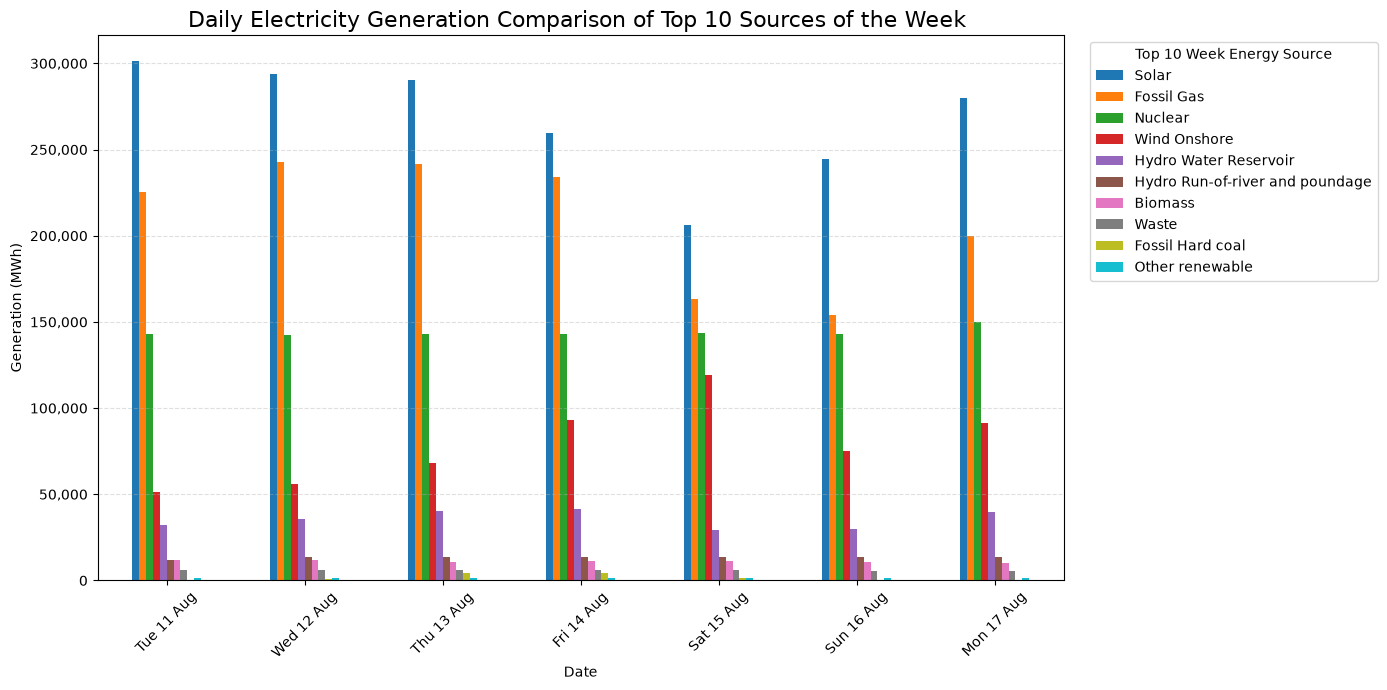

In [12]:
# Plot -> bar chart of daily top_n source GENERATION 

top_n = 10 # find the n largest generation sources

top_sources = (
    daily_generation_mwh
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)


fig, ax = plt.subplots(figsize=(14, 7))

daily_generation_mwh[top_sources].plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    f"Daily Electricity Generation Comparison of Top {top_n} Sources of the Week ",
    fontsize=16,
    # fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_xticklabels(
    daily_generation_mwh.index.strftime("%a %d %b"),
    rotation=0
)


ax.set_ylabel("Generation (MWh)")
ax.yaxis.set_major_formatter( FuncFormatter(lambda x, pos: f"{x:,.0f}") )

ax.legend(
    title=f"Top {top_n} Week Energy Source",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



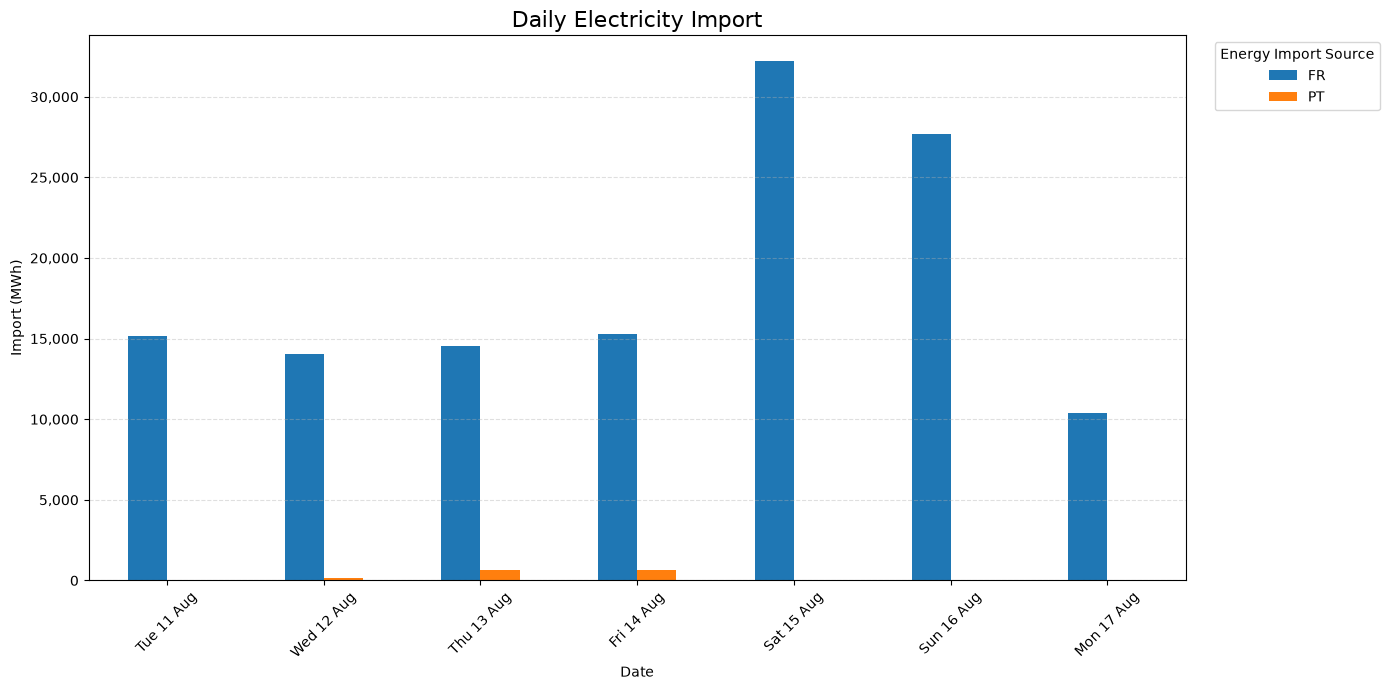

In [13]:
# Plot -> bar chart of daily IMPORT 

fig, ax = plt.subplots(figsize=(14, 7))

daily_import_mwh.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    f"Daily Electricity Import",
    fontsize=16,
)

ax.set_xlabel("Date")
ax.set_xticklabels(
    daily_import_mwh.index.strftime("%a %d %b"),
    rotation=0
)


ax.set_ylabel("Import (MWh)")
ax.yaxis.set_major_formatter( FuncFormatter(lambda x, pos: f"{x:,.0f}") )

ax.legend(
    title=f"Energy Import Source",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

